In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [2]:
data24 = pd.read_pickle('data24_magup_200_all.pkl')
mc_data = pd.read_pickle('mc_data_all.pkl')

Aqui hay que añadir las nuevas variables del DOCA y IP 

In [3]:
training_keys = ['Jpsi_PT','Jpsi_MAXDOCA', 'Jpsi_BPVDIRA', 'Jpsi_ETA', 
            'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2', 'L_PT','L_P', 'L_CHI2','L_END_VZ','L_END_VX', 'L_END_VY', 'L_MASS',
            'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT','Lb_CHI2','Lb_MINIPCHI2',  'Lb_ETA', 
            'p_PID_P', 'p_MINIP', 'p_P', 'p_PT', 'p_ETA','p_GHOSTPROB',
            'mup_PID_MU',
            'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB'] +['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP','DOCA','p_RK_IP','pim_RK_IP']

In [4]:
# data24 = data24_rude.query('(DOCA < 100 )')

In [5]:
mc_data

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,Jpsi_END_VX,...,pim_PZ_V,pim_X_V,pim_Y_V,p_TX,p_TY,pim_TX,pim_TY,DOCA,p_RK_IP,pim_RK_IP
0,1078.216064,5238.732910,3095.558350,48452.062500,915.653381,0.299717,0.015202,0.999958,1.093754,0.9605,...,6710.756846,28.058425,-85.573801,0.028349,-0.024032,-0.178990,-0.023108,28.005986,20.274236,53.533973
1,1078.259033,5257.361816,3014.794678,145656.640625,6167.957520,0.607561,0.013176,0.999846,1.118636,1.0240,...,8474.719763,-151.644042,-73.383949,-0.061371,-0.024246,0.075773,-0.023438,0.688003,47.748954,17.751376
2,1078.478394,5378.423828,3104.240234,107524.718750,6373.708984,0.386113,0.031794,0.999907,1.743110,1.5966,...,15924.109550,94.984516,-179.394918,0.007876,-0.042783,0.016770,-0.043573,0.342831,36.717005,317.756497
3,1078.545044,5452.856934,3114.653809,75249.507812,12491.000000,2.606676,0.030760,0.998852,1.256283,1.1800,...,4499.429765,460.188046,-250.966940,0.097050,-0.044477,0.066274,-0.039301,1.964708,142.260138,1106.174407
4,1078.846558,5150.160645,3109.953369,58382.671875,2565.219727,1.778421,0.030807,0.999737,1.657983,1.5057,...,5194.596327,551.206529,185.567668,0.084514,0.028904,0.097336,0.026315,1.887912,193.641135,1220.761827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60158,1699.889526,6187.048340,3113.975098,182840.265625,4920.676758,2.760785,0.033684,0.999967,1.260225,1.1663,...,10759.950513,-4.171114,-92.148110,0.052126,-0.023856,-0.094271,-0.046223,35.922793,11.415949,101.780203
60159,1699.902954,5329.004395,3107.208496,34801.566406,862.707825,2.338604,0.085805,0.999984,0.992543,0.9334,...,4930.819710,-44.712528,110.309432,0.009876,0.030760,-0.133941,0.043626,25.148504,173.076008,438.230905
60160,1699.963257,5403.758301,3102.406738,30079.544922,1179.017822,0.439143,0.017408,0.999255,1.220537,1.1252,...,7518.608254,105.573573,323.124345,0.000743,0.109228,0.056674,0.109514,1.631750,111.875900,423.918988
60161,1699.978271,6048.416992,3103.485107,179971.515625,9405.648438,1.092537,0.014153,0.999942,1.145118,1.0980,...,6395.929357,2.757377,-86.124568,0.061690,-0.018446,-0.152039,-0.002582,63.131394,7.296131,120.916184


In [6]:
to_drop1 = [x for x in mc_data.columns if x not in training_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']+ ['L_MASS']+ ['MAGFIELD']]
to_drop2 = [x for x in data24.columns if x not in training_keys + ['Lb_MASS']+ ['L_MASS']]

In [7]:
print(to_drop1)
print(to_drop2)

['Jpsi_MASS', 'Jpsi_P', 'Jpsi_CHI2', 'Jpsi_END_VRHO', 'Jpsi_END_VX', 'Jpsi_END_VY', 'Jpsi_END_VZ', 'Jpsi_BPVIP', 'Jpsi_MINIPCHI2', 'L_PX', 'L_PY', 'L_PZ', 'L_BPVFDCHI2', 'L_MINIPCHI2', 'Lb_PX', 'Lb_PY', 'Lb_PZ', 'Lb_BPVIPCHI2', 'Lb_BPVFDCHI2', 'p_PX', 'p_PY', 'p_PZ', 'p_PID_K', 'pim_PX', 'pim_PY', 'pim_PZ', 'mum_P', 'mum_PT', 'mum_PX', 'mum_PY', 'mum_PZ', 'mum_CHI2', 'mum_GHOSTPROB', 'mum_PID_P', 'mum_PID_K', 'mum_PID_MU', 'mum_PID_E', 'mum_MINIP', 'mum_MINIPCHI2', 'mup_P', 'mup_PT', 'mup_PX', 'mup_PY', 'mup_PZ', 'mup_CHI2', 'mup_GHOSTPROB', 'mup_PID_P', 'mup_PID_K', 'mup_PID_E', 'mup_MINIP', 'mup_MINIPCHI2', 'totCandidates', 'p_QOVERP', 'pim_QOVERP', 'Lb_END_VX', 'Lb_END_VY', 'Lb_END_VZ', 'L_TRUEP', 'L_TRUEPX', 'L_TRUEPY', 'L_TRUEPZ', 'p_TRUEP', 'p_TRUEPX', 'p_TRUEPY', 'p_TRUEPZ', 'pim_TRUEP', 'pim_TRUEPX', 'pim_TRUEPY', 'pim_TRUEPZ', 'L_TRUEID', 'pim_TRUEID', 'p_TRUEID', 'p_TRUEENERGY', 'pim_TRUEENERGY', 'L_TRUEENERGY', 'p_MC_GD_MOTHER_ID', 'p_MC_MOTHER_ID', 'pim_MC_GD_MOTHER_ID', 'p

In [8]:
mc_data.drop(columns=to_drop1, inplace=True)
data24.drop(columns=to_drop2, inplace=True)

In [9]:
mc_data.keys

<bound method NDFrame.keys of             L_MASS      Lb_MASS       Jpsi_PT  Jpsi_MAXDOCA  Jpsi_BPVDIRA  \
0      1078.216064  5238.732910    915.653381      0.015202      0.999958   
1      1078.259033  5257.361816   6167.957520      0.013176      0.999846   
2      1078.478394  5378.423828   6373.708984      0.031794      0.999907   
3      1078.545044  5452.856934  12491.000000      0.030760      0.998852   
4      1078.846558  5150.160645   2565.219727      0.030807      0.999737   
...            ...          ...           ...           ...           ...   
60158  1699.889526  6187.048340   4920.676758      0.033684      0.999967   
60159  1699.902954  5329.004395    862.707825      0.085805      0.999984   
60160  1699.963257  5403.758301   1179.017822      0.017408      0.999255   
60161  1699.978271  6048.416992   9405.648438      0.014153      0.999942   
60162  1699.979370  6403.832031   4662.819336      0.014034      0.999882   

                 L_P         L_PT     L_CHI2 

In [10]:
data24

,L_MASS,Lb_MASS,Jpsi_PT,Jpsi_ETA,Jpsi_MAXDOCA,Jpsi_BPVDIRA,L_P,L_PT,L_CHI2,L_END_VZ,...,pim_GHOSTPROB,mup_PID_MU,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2,DOCA,p_RK_IP,pim_RK_IP
0,1077.888062,5138.754883,723.915100,4.456281,0.029443,0.999971,23857.281250,3761.958496,0.000919,6019.591309,...,0.125024,5.678733,0.999976,0.995220,0.006897,0.097816,12.795047,0.796099,220.922003,1722.259853
1,1077.960083,6229.182129,3090.029541,4.297313,0.014289,0.999726,27599.062500,2304.890381,3.208001,3487.430420,...,0.011511,2.174705,0.999478,0.998819,0.032320,0.048610,41.460577,11.490942,56.071999,355.185789
2,1077.994873,5330.297363,1293.958008,3.833884,0.038910,0.999779,28786.494141,1230.367798,0.069680,4361.624023,...,0.017818,12.194980,0.999769,0.999334,0.021490,0.036488,36.237925,2.610931,191.919581,613.527293
3,1078.056641,5357.426758,331.198547,5.062816,0.036069,0.997673,114750.609375,3638.914062,13.445335,3244.278809,...,0.295621,7.600204,0.999997,0.999918,0.002238,0.012822,16.963174,2.828152,70.772699,376.668317
4,1078.200317,5082.967285,794.785339,4.411172,0.056496,0.999893,27813.748047,1756.336792,0.149619,4694.435059,...,0.065842,8.291490,0.999625,0.999961,0.027390,0.008850,34.461965,5.070011,183.687019,462.104796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378180,1699.999268,5328.585937,553.602600,5.051987,0.030286,0.998830,49871.000000,1566.895630,0.176289,3531.650391,...,0.013952,7.790074,0.999997,0.999956,0.002584,0.009430,10.601626,2.702120,163.021371,277.213024
3378181,1699.999390,5979.778809,7499.708496,3.808616,0.019194,0.999975,54892.554688,1918.696899,42.245869,7215.124512,...,0.523989,3.514266,0.999494,0.999146,0.031817,0.041338,78.795889,13.639055,6.477182,129.490238
3378182,1699.999634,5248.484863,1637.624390,3.622277,0.003342,0.994836,48508.648438,1177.389893,12.774581,5386.837891,...,0.002585,0.817017,0.998355,0.998729,0.057364,0.050424,40.323489,16.050389,109.840419,68.407009
3378183,1699.999634,6159.836914,2500.225830,5.236960,0.049638,0.999985,43291.304688,1068.294678,43.265739,5734.793457,...,0.020170,2.361520,0.998917,0.998701,0.046541,0.050974,56.834362,16.083140,70.597065,202.693762


In [11]:
training_data = mc_data[mc_data['MAGFIELD'] == True].copy() # True for MagUP and False for MagDown
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) & (training_data['L_MASS'] < 1300) 
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True

In [12]:
print(len(training_data.query('(SIGNAL)')['SIGNAL']))

12507


In [13]:
new_training = pd.DataFrame(columns=training_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
# new_training = new_training.merge(data24_selected,how='outer')
new_training = new_training.merge(data24.query('(L_MASS > 1300) & (L_MASS < 1700) '),how='outer')

# new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6200) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_14588/1055856324.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [14]:
print(len(new_training.query('(CLASS ==0) ')['CLASS']))
print(len(new_training.query('(CLASS !=0) ')['CLASS']))

12507
2039536


In [15]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [16]:
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP', 'L_MASS', 'MAGFIELD'] #, ,'xi_L', 'xi_Lb'
# to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','xi_LbP', 'xi_LP'] #, 'Cos_xi_LbP','Cos_xi_LP'

In [17]:
X_tr, X_eval = train_test_split(new_training)
y_tr = X_tr.SIGNAL
y_tr_clean = y_tr == True
X_tr_copy = X_tr.copy()
X_tr.drop(columns=to_drop, inplace=True)

y_eval =  X_eval.SIGNAL
y_eval_clean = y_eval == True
X_eval_copy = X_eval.copy()
X_eval.drop(columns=to_drop, inplace=True)

In [18]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced',
    'random_seed' : 69
}

In [19]:
train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))
eval_dataset = Pool(X_eval, y_eval_clean, feature_names=list(X_eval.columns))

In [20]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=True, plot=False)

Learning rate set to 0.236531
0:	learn: 0.3659122	total: 237ms	remaining: 3m 56s
1:	learn: 0.2320156	total: 393ms	remaining: 3m 15s
2:	learn: 0.1707524	total: 561ms	remaining: 3m 6s
3:	learn: 0.1450886	total: 711ms	remaining: 2m 57s
4:	learn: 0.1242936	total: 865ms	remaining: 2m 52s
5:	learn: 0.1121754	total: 1.02s	remaining: 2m 49s
6:	learn: 0.1027477	total: 1.17s	remaining: 2m 46s
7:	learn: 0.0967669	total: 1.32s	remaining: 2m 44s
8:	learn: 0.0904316	total: 1.47s	remaining: 2m 41s
9:	learn: 0.0854575	total: 1.62s	remaining: 2m 40s
10:	learn: 0.0818749	total: 1.77s	remaining: 2m 38s
11:	learn: 0.0787148	total: 1.92s	remaining: 2m 37s
12:	learn: 0.0765192	total: 2.06s	remaining: 2m 36s
13:	learn: 0.0743857	total: 2.21s	remaining: 2m 35s
14:	learn: 0.0727040	total: 2.36s	remaining: 2m 34s
15:	learn: 0.0699667	total: 2.51s	remaining: 2m 34s
16:	learn: 0.0676490	total: 2.65s	remaining: 2m 33s
17:	learn: 0.0659568	total: 2.8s	remaining: 2m 32s
18:	learn: 0.0643311	total: 2.94s	remaining: 2

34:	learn: 0.0492252	total: 5.28s	remaining: 2m 25s
35:	learn: 0.0486325	total: 5.44s	remaining: 2m 25s
36:	learn: 0.0477541	total: 5.59s	remaining: 2m 25s
37:	learn: 0.0474510	total: 5.73s	remaining: 2m 24s
38:	learn: 0.0469639	total: 5.87s	remaining: 2m 24s
39:	learn: 0.0462644	total: 6.03s	remaining: 2m 24s
40:	learn: 0.0455162	total: 6.17s	remaining: 2m 24s
41:	learn: 0.0448830	total: 6.33s	remaining: 2m 24s
42:	learn: 0.0443318	total: 6.47s	remaining: 2m 24s
43:	learn: 0.0438279	total: 6.62s	remaining: 2m 23s
44:	learn: 0.0433786	total: 6.77s	remaining: 2m 23s
45:	learn: 0.0429862	total: 6.92s	remaining: 2m 23s
46:	learn: 0.0426486	total: 7.07s	remaining: 2m 23s
47:	learn: 0.0423963	total: 7.2s	remaining: 2m 22s
48:	learn: 0.0419720	total: 7.34s	remaining: 2m 22s
49:	learn: 0.0414409	total: 7.48s	remaining: 2m 22s
50:	learn: 0.0411757	total: 7.62s	remaining: 2m 21s
51:	learn: 0.0407079	total: 7.77s	remaining: 2m 21s
52:	learn: 0.0404543	total: 7.92s	remaining: 2m 21s
53:	learn: 0.

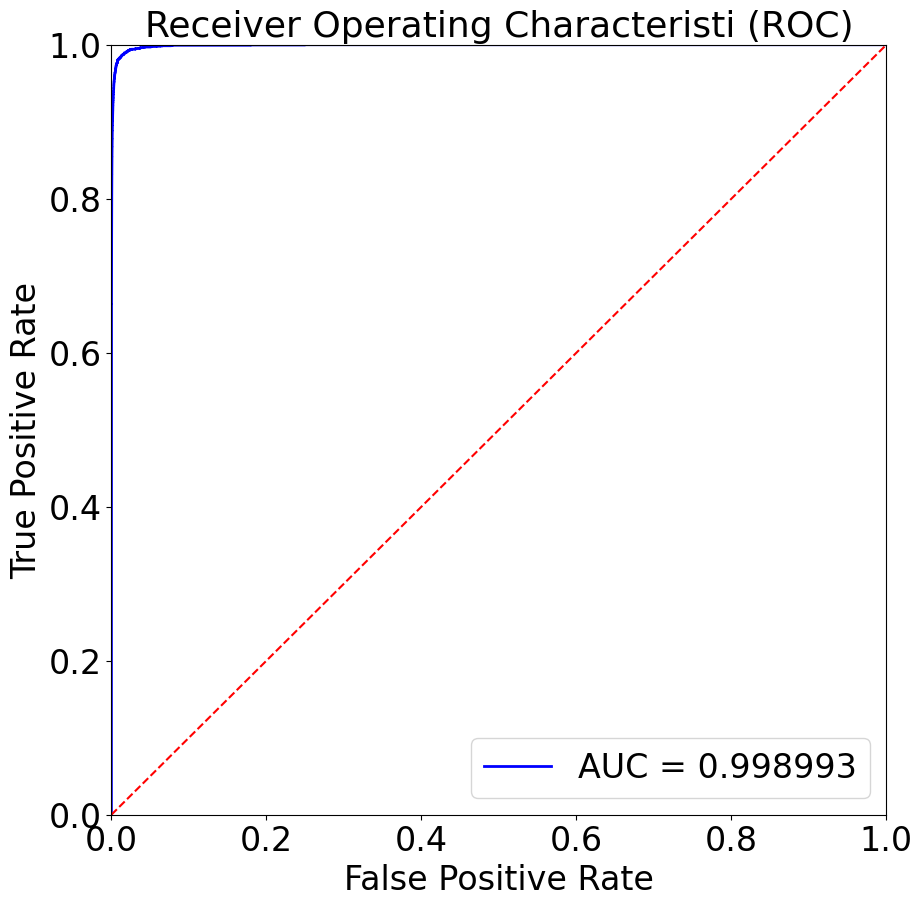

In [21]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_eval)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_eval, preds)
roc_auc = metrics.auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,10)
plt.title('Receiver Operating Characteristi (ROC)', fontsize=26)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=24)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=24)
plt.xlabel('False Positive Rate', fontsize=24)
plt.xticks(fontsize=24) 
plt.yticks(fontsize=24) 
plt.show()

In [22]:
print(model.get_best_score())
print(model.get_all_params())

{'learn': {'Accuracy:use_weights=true': 0.9983596718440378, 'Logloss:use_weights=false': 0.009470654830837505, 'Logloss:use_weights=true': 0.007116543203041112, 'Logloss': 0.007116543203041112, 'Accuracy:use_weights=false': 0.9967395089900665, 'AUC': 0.9998849781184074}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39],
 [Text(0, 0, 'L_BPVDIRA'),
  Text(0, 1, 'Lb_MAXDOCA'),
  Text(0, 2, 'L_END_VY'),
  Text(0, 3, 'L_END_VX'),
  Text(0, 4, 'xi_LbP'),
  Text(0, 5, 'Jpsi_PT'),
  Text(0, 6, 'p_ETA'),
  Text(0, 7, 'Jpsi_ETA'),
  Text(0, 8, 'Lb_PT'),
  Text(0, 9, 'L_CHI2'),
  Text(0, 10, 'Lb_CHI2'),
  Text(0, 11, 'L_BPVIP'),
  Text(0, 12, 'L_BPVIPCHI2'),
  Text(0, 13, 'Jpsi_MAXDOCA'),
  Text(0, 14, 'Lb_P'),
  Text(0, 15, 'mup_PID_MU'),
  Text(0, 16, 'p_RK_IP'),
  Text(0, 17, 'p_PT'),
  Text(0, 18, 'p_PID_P'),
  Text(0, 19, 'pim_ETA'),
  Text(0, 20, 'Lb_ETA'),
  Text(0, 21, 'p_P'),
  Text(0, 22, 'pim_PT'),
  Text(0, 23, 'L_PT'),
  Text(0, 24, 'pim_RK_IP'),
  Text(0, 25, 'L_END_VRHO'),
  Text(0, 26, 'Lb_MINIPCHI2'),
  Text(0, 27, 'pim_GHOSTPROB'),
  Text(0, 28, 'Jpsi_BPVDIRA'),
  Tex

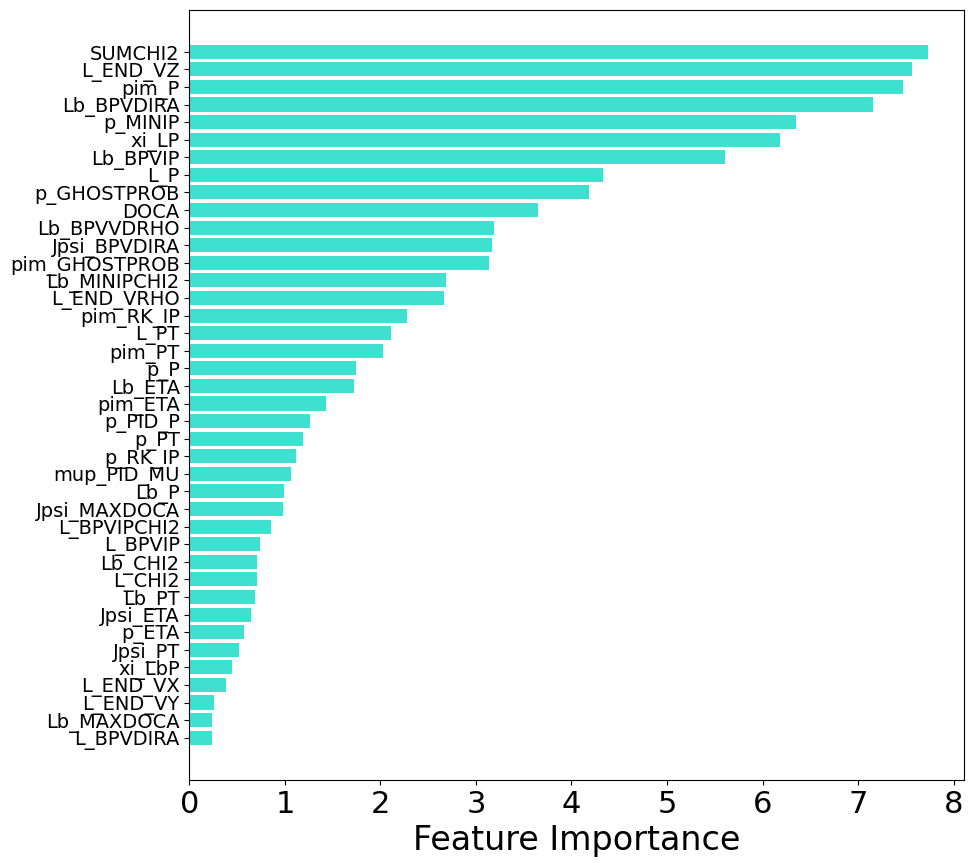

In [23]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (10,10)
plt.barh(X_eval.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("Feature Importance", fontsize=24)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
# plt.title("Feature Importance", fontsize=24)
plt.xticks(fontsize=22)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=14)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

In [24]:
signal_MVA_prob_eval = model.predict_proba(X_eval_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
X_eval_copy['signal_MVA'] = signal_MVA_probs

signal_MVA_prob_tr = model.predict_proba(X_tr_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_tr]
X_tr_copy['signal_MVA'] = signal_MVA_probs

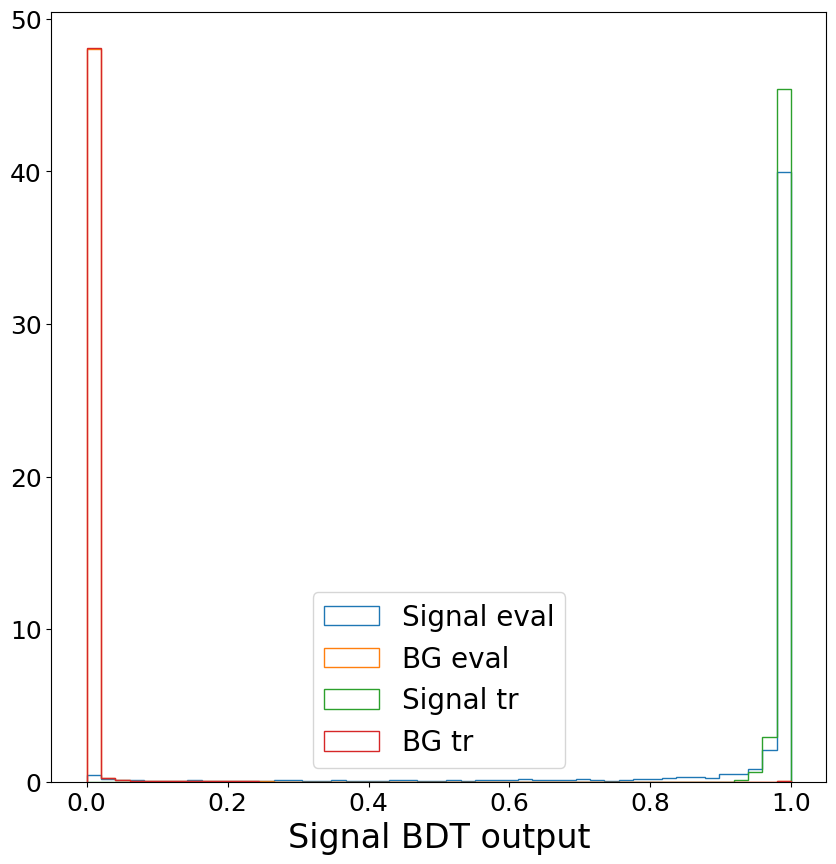

In [25]:
fig, ax = plt.subplots()

density = True

variable = 'signal_MVA'

bins = np.linspace(0,1,50)

n_sig,bins_sig, _ = ax.hist(X_eval_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal eval",histtype='step',density=density)
n_bg,bins_bg, _ = ax.hist(X_eval_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG eval",histtype='step',density=density)

ax.hist(X_tr_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal tr",histtype='step',density=density)
ax.hist(X_tr_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG tr",histtype='step',density=density)

ax.legend(fontsize=20)  # Ajusta el tamaño de fuente de la leyenda
ax.set_xlabel("Signal BDT output", fontsize=24)  # Ajusta el tamaño de fuente del eje x
plt.rcParams["figure.figsize"] = (15,10)
# Ajusta el tamaño de fuente de las marcas en los ejes x e y
# ax.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(fontsize=18)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

plt.show()

Guarda el modelo para ser utilizado posteriormente

In [26]:
model.save_model('BDT_MagUP_all',
           format="cbm",
           export_parameters=None,
           pool=None)

In [27]:
for SIGNAL in [True, False]:
    print(f'SIGNAL == {SIGNAL}', len(new_training.query(f'(SIGNAL == {SIGNAL})')))

SIGNAL == True 12507
SIGNAL == False 2039536
